In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['OPENAI_API_KEY']:
    print("API key is set.")
else: 
    print("API key is not set.")   


API key is set.


In [2]:
llm=ChatOpenAI(model="gpt-4.1-mini", temperature=0)
llm.invoke("What is the capital of France?").content

'The capital of France is Paris.'

###Pydantic Schema

In [5]:
from pydantic import BaseModel,Field

class graph_schema(BaseModel):
    topic:str = Field(description="The topic of the graph")
    post:str = Field(description="A LinkedIn post about the topic")
    curated_post:str = Field(description="A curated version of the post")


demo_obj = graph_schema(topic="AI",
                        post="AI is transforming the world!",
                        curated_post="AI is revolutionizing industries and shaping the future.")

print(demo_obj)    

topic='AI' post='AI is transforming the world!' curated_post='AI is revolutionizing industries and shaping the future.'


In [6]:
def create_post(state:graph_schema)->graph_schema:
    topic=state.topic
    post =llm.invoke(f"Write a LinkedIn post about {topic}").content

    state.post=post
    return state
    
    

In [18]:
def curated_post(state:graph_schema)->graph_schema:
    post=state.post
    curated_post =llm.invoke(f"Curate the following LinkedIn post to make it more engaging: {post}").content

    state.curated_post=curated_post
    return state

In [19]:
from langgraph.graph import StateGraph,START,END
graph = StateGraph(graph_schema)
graph.add_node("create_post",create_post)
graph.add_node("curated_post",curated_post)

graph.add_edge(START,"create_post")

graph.add_edge("create_post","curated_post")

graph.add_edge("curated_post",END)


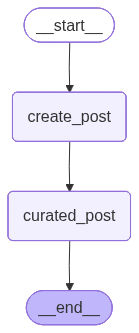

In [20]:
from IPython.display import Image,display
second_graph = graph.compile()
Image(second_graph.get_graph().draw_mermaid_png())

In [24]:
second_graph.invoke({"topic":"AI","post":"","curated_post":""})

{'topic': 'AI',
 'post': 'Absolutely! Here’s a LinkedIn post about AI:\n\n---\n\n🚀 Embracing the Future with AI 🚀\n\nArtificial Intelligence is no longer just a buzzword — it’s transforming the way we live, work, and innovate. From automating routine tasks to unlocking insights from vast amounts of data, AI is empowering businesses to make smarter decisions and drive meaningful impact.\n\nBut beyond the technology, it’s about people. AI enables us to focus on creativity, strategy, and human connection — areas where machines can’t replace us.\n\nAs we continue to integrate AI into our workflows, let’s prioritize ethical use, transparency, and continuous learning to harness its full potential responsibly.\n\nHow is AI shaping your industry or role? I’d love to hear your experiences and thoughts!\n\n#ArtificialIntelligence #AI #Innovation #FutureOfWork #TechForGood\n\n---\n\nWould you like it tailored to a specific industry or tone?',
 'curated_post': "Certainly! Here's a more engaging an